In [1]:
# Linear Regression using PyTorch

#import necessary libraries
import torch
import torch.nn as nn
from tqdm import tqdm

# Check for GPU availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Generate synthetic data
x_train = torch.tensor([x for x in range(10)])
y_train = torch.tensor([2 * x + 5 for x in range(10)])

# Define the model
class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear1 = nn.Linear(1, 50)
        self.linear2 = nn.Linear(50, 1)

    def forward(self, x):
        x = self.linear1(x)
        x = self.linear2(x)
        return x

# Initialize model, loss function, and optimizer
model = LinearRegressionModel().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
num_epochs = 1000

# Training loop
def train():
    #track progress in epochs
    pbar = tqdm(total=num_epochs, desc="Training", unit="step")

    for epoch in range(num_epochs):
        model.train()

        for i in range(len(x_train)):
            inputs = x_train[i].view(1, -1).float().to(device)
            targets = y_train[i].view(1, -1).float().to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()


        pbar.set_postfix(epoch=epoch+1, loss=loss.item())
        pbar.update(1)

    pbar.close()

train()

# Save the model
torch.save(model.state_dict(), 'linear_regression_model.pth')
print("Model saved to linear_regression_model.pth")

# Load the model
model_loaded = LinearRegressionModel().to(device)
model_loaded.load_state_dict(torch.load('linear_regression_model.pth'))

#infernce
def infernce(input_value):
    model_loaded.eval()
    with torch.no_grad():
        input_tensor = torch.tensor([[input_value]]).float().to(device)
        predicted = model_loaded(input_tensor)
        return predicted.item()

# Example inference
if __name__ == "__main__":
    test_value = 15
    prediction = infernce(test_value)
    print(f'Prediction for input {test_value}: {prediction}')

Using device: cuda


Training: 100%|██████████| 1000/1000 [00:13<00:00, 71.53step/s, epoch=1000, loss=1.5e-5]


Model saved to linear_regression_model.pth
Prediction for input 15: 35.002197265625


In [2]:
import torch

state = torch.load("/content/linear_regression_model.pth", map_location="cpu")

# if saved as state_dict
if isinstance(state, dict) and not hasattr(state, "parameters"):
    total_params = sum(v.numel() for v in state.values())
else:
    # if full model was saved
    total_params = sum(p.numel() for p in state.parameters())

print(total_params)


151


In [3]:
import torch

state = torch.load("/content/linear_regression_model.pth", map_location="cpu")

# state_dict case
if isinstance(state, dict) and not hasattr(state, "parameters"):
    for name, tensor in state.items():
        print(name, tensor.shape, tensor.numel())
else:
    # full model case
    for name, param in state.named_parameters():
        print(name, param.shape, param.numel())


linear1.weight torch.Size([50, 1]) 50
linear1.bias torch.Size([50]) 50
linear2.weight torch.Size([1, 50]) 50
linear2.bias torch.Size([1]) 1


In [4]:
import torch

state = torch.load("/content/linear_regression_model.pth", map_location="cpu")

# state_dict case
if isinstance(state, dict) and not hasattr(state, "parameters"):
    for name, tensor in state.items():
        print(f"\n{name} | shape={tuple(tensor.shape)}")
        print(tensor)
else:
    # full model case
    for name, param in state.named_parameters():
        print(f"\n{name} | shape={tuple(param.shape)}")
        print(param.data)



linear1.weight | shape=(50, 1)
tensor([[-0.9038],
        [ 0.1857],
        [ 0.3272],
        [-0.6483],
        [-0.6326],
        [ 0.1776],
        [ 0.1778],
        [-1.0257],
        [-0.9783],
        [-0.3496],
        [-0.5242],
        [-0.2609],
        [-0.6348],
        [-0.1365],
        [-0.7684],
        [-0.9782],
        [ 0.6807],
        [ 0.9160],
        [ 0.0785],
        [ 0.3369],
        [-0.8025],
        [-0.6309],
        [ 0.6146],
        [-0.3180],
        [ 0.4742],
        [-0.9170],
        [ 0.5615],
        [-1.0706],
        [-0.9415],
        [ 0.0897],
        [-0.3226],
        [ 0.8259],
        [ 0.1629],
        [-0.3613],
        [-0.5849],
        [ 0.8832],
        [-0.5261],
        [-1.0514],
        [ 0.8678],
        [ 0.4399],
        [ 0.6617],
        [ 0.8064],
        [-0.7801],
        [ 0.3146],
        [ 0.6662],
        [ 0.4287],
        [-0.7851],
        [ 0.8777],
        [ 0.1314],
        [-0.4217]])

linear1.bias | s

(151,)


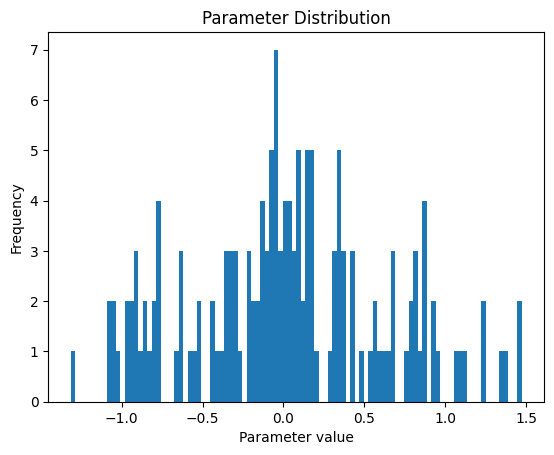

In [5]:
import torch
import matplotlib.pyplot as plt

state = torch.load("/content/linear_regression_model.pth", map_location="cpu")

values = []

# state_dict case
if isinstance(state, dict) and not hasattr(state, "parameters"):
    for tensor in state.values():
        values.append(tensor.detach().cpu().view(-1))
else:
    # full model case
    for p in state.parameters():
        values.append(p.detach().cpu().view(-1))

values = torch.cat(values).numpy()
print(values.shape)
plt.hist(values, bins=100)
plt.xlabel("Parameter value")
plt.ylabel("Frequency")
plt.title("Parameter Distribution")
plt.show()


In [6]:
import torch

state = torch.load("/content/linear_regression_model.pth", map_location="cpu")

# collect params
params = []
if isinstance(state, dict):
    for v in state.values():
        params.append(v)
else:
    for p in state.parameters():
        params.append(p)

num_params = sum(p.numel() for p in params)
bytes_size = sum(p.numel() * p.element_size() for p in params)

print(f"Parameters: {num_params}")
print(f"Model size: {bytes_size} bytes")
print(f"Model size: {bytes_size/1024:.2f} KB")
print(f"Model size: {bytes_size/1024/1024:.4f} MB")


Parameters: 151
Model size: 604 bytes
Model size: 0.59 KB
Model size: 0.0006 MB


In [7]:
# simple symmetric int8 quantization
import torch

state = torch.load("/content/linear_regression_model.pth", map_location="cpu")
q_state = {}

for k, v in state.items():
    scale = v.abs().max() / 127
    q = torch.round(v / scale).to(torch.int8)
    q_state[k] = {"q": q, "scale": scale}

torch.save(q_state, "model_int8.pth")


In [8]:
import torch

state = torch.load("model_int8.pth", map_location="cpu")

size_bytes = 0
for v in state.values():
    size_bytes += v["q"].numel() * v["q"].element_size()  # int8 weights
    size_bytes += 4  # float32 scale

print(f"Quantized model size (raw): {size_bytes} bytes")


Quantized model size (raw): 167 bytes


In [9]:
state.keys()

dict_keys(['linear1.weight', 'linear1.bias', 'linear2.weight', 'linear2.bias'])

In [10]:
state["linear1.weight"]

{'q': tensor([[-107],
         [  22],
         [  39],
         [ -77],
         [ -75],
         [  21],
         [  21],
         [-122],
         [-116],
         [ -41],
         [ -62],
         [ -31],
         [ -75],
         [ -16],
         [ -91],
         [-116],
         [  81],
         [ 109],
         [   9],
         [  40],
         [ -95],
         [ -75],
         [  73],
         [ -38],
         [  56],
         [-109],
         [  67],
         [-127],
         [-112],
         [  11],
         [ -38],
         [  98],
         [  19],
         [ -43],
         [ -69],
         [ 105],
         [ -62],
         [-125],
         [ 103],
         [  52],
         [  78],
         [  96],
         [ -93],
         [  37],
         [  79],
         [  51],
         [ -93],
         [ 104],
         [  16],
         [ -50]], dtype=torch.int8),
 'scale': tensor(0.0084)}

In [11]:
print(state)

{'linear1.weight': {'q': tensor([[-107],
        [  22],
        [  39],
        [ -77],
        [ -75],
        [  21],
        [  21],
        [-122],
        [-116],
        [ -41],
        [ -62],
        [ -31],
        [ -75],
        [ -16],
        [ -91],
        [-116],
        [  81],
        [ 109],
        [   9],
        [  40],
        [ -95],
        [ -75],
        [  73],
        [ -38],
        [  56],
        [-109],
        [  67],
        [-127],
        [-112],
        [  11],
        [ -38],
        [  98],
        [  19],
        [ -43],
        [ -69],
        [ 105],
        [ -62],
        [-125],
        [ 103],
        [  52],
        [  78],
        [  96],
        [ -93],
        [  37],
        [  79],
        [  51],
        [ -93],
        [ 104],
        [  16],
        [ -50]], dtype=torch.int8), 'scale': tensor(0.0084)}, 'linear1.bias': {'q': tensor([ -46,  -94,  -32,   76,   58,   92,   96,  -70,  -27, -114,  -79,  -37,
           9,  -74,  -77,  